In [36]:
# Imports and basic display settings
import os
import re
import json
import joblib
import tempfile
import sys
import shutil
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression, Ridge, LassoCV, ElasticNetCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR

pd.set_option('display.float_format', lambda x: f'{x:.4f}')

try:
    get_ipython().run_line_magic('matplotlib', 'inline')
except Exception:
    pass


In [37]:
# Load the processed master table
if Path('data/processed/bgg_master.csv').exists():
    DATA_PATH = Path('data/processed/bgg_master.csv')
elif Path('../data/processed/bgg_master.csv').exists():
    DATA_PATH = Path('../data/processed/bgg_master.csv')
else:
    raise FileNotFoundError('Could not find bgg_master.csv from current working directory.')

df = pd.read_csv(DATA_PATH)
print('Loaded:', DATA_PATH.resolve())
print('Shape:', df.shape)
print('AvgRating exists:', 'AvgRating' in df.columns)


Loaded: C:\Users\guy74\Documents\NU Stuff\ANA680\Week 4\Final Project Board Game Ratings Predictions\Board Game Ratings Predictions\data\processed\bgg_master.csv
Shape: (21925, 217)
AvgRating exists: True


In [38]:
# Next we'll exclude some columns which could "leak" info about the ratings either directly or indirectly
# Then we'll keep only numeric predictors and build X/y cleanly.
target_col = 'AvgRating'

must_remove_for_prediction = {
    'BGGId', 'Name', 'Description', 'ImagePath', 'AvgRating',
    'BayesAvgRating', 'StdDev',
    'NumOwned', 'NumWant', 'NumWish', 'NumWeightVotes', 'NumUserRatings', 'NumComments',
    'NumAlternates', 'NumExpansions', 'NumImplementations',
    'Rank_boardgame', 'Rank_strategygames', 'Rank_abstracts', 'Rank_familygames',
    'Rank_thematic', 'Rank_cgs', 'Rank_wargames', 'Rank_partygames', 'Rank_childrensgames',
    'ComAgeRec', 'LanguageEase', 'BestPlayers', 'GoodPlayers', 'ComMinPlaytime', 'ComMaxPlaytime',
    'HasMechanicsData', 'HasSubcategoryData', 'Family'
}

exclude_from_X = sorted(must_remove_for_prediction - {target_col})
present_exclusions = [c for c in exclude_from_X if c in df.columns]
valid_columns = [c for c in df.columns if c not in present_exclusions]
df_valid = df[valid_columns].copy()

target_missing_count = int(df_valid[target_col].isna().sum())

print('Original column count:', len(df.columns))
print('Excluded column count (present in df):', len(present_exclusions))
print('Remaining column count (including target):', len(df_valid.columns))
print('Missing rows in target AvgRating:', target_missing_count)

# Add small engineered count features in one concat step (avoids fragmentation warnings)
mech_feature_cols = [c for c in df_valid.columns if c.startswith('mech_')]
subcat_feature_cols = [c for c in df_valid.columns if c.startswith('subcat_')]

engineered = {}
if mech_feature_cols:
    engineered['num_mechanics_active'] = df_valid[mech_feature_cols].sum(axis=1).astype(int)
if subcat_feature_cols:
    engineered['num_subcats_active'] = df_valid[subcat_feature_cols].sum(axis=1).astype(int)
if engineered:
    df_valid = pd.concat([df_valid, pd.DataFrame(engineered, index=df_valid.index)], axis=1)

# For indicator blocks, missing means not present -> set to 0
indicator_cols = [c for c in df_valid.columns if c.startswith('mech_') or c.startswith('subcat_')]
indicator_missing_count = int(df_valid[indicator_cols].isna().sum().sum()) if indicator_cols else 0
if indicator_missing_count > 0:
    df_valid[indicator_cols] = df_valid[indicator_cols].fillna(0)
print('Indicator missing values filled with 0:', indicator_missing_count)

predictor_cols = [c for c in df_valid.columns if c != target_col]
non_numeric_predictors = [c for c in predictor_cols if not pd.api.types.is_numeric_dtype(df_valid[c])]
if non_numeric_predictors:
    print('Dropping non-numeric predictors:', non_numeric_predictors)

numeric_predictor_cols = [c for c in predictor_cols if c not in non_numeric_predictors]

X = df_valid[numeric_predictor_cols].copy()
y = pd.to_numeric(df_valid[target_col], errors='coerce')

# Do not silently impute here; fail fast if unexpected missing predictors remain
remaining_missing_in_X = int(X.isna().sum().sum())
print('Remaining missing predictor values in X:', remaining_missing_in_X)
if remaining_missing_in_X > 0:
    missing_cols = X.columns[X.isna().any()].tolist()
    raise ValueError(f'Unexpected missing predictor values remain in columns: {missing_cols}')

print('Final predictor column count:', X.shape[1])
print('Row count for X/y:', X.shape[0], '/', y.shape[0])


Original column count: 217
Excluded column count (present in df): 33
Remaining column count (including target): 184
Missing rows in target AvgRating: 0
Indicator missing values filled with 0: 0
Remaining missing predictor values in X: 0
Final predictor column count: 185
Row count for X/y: 21925 / 21925


In [39]:
# Optional quick feature list audit
feature_audit = pd.DataFrame({'feature': X.columns, 'dtype': X.dtypes.astype(str)})
#display(feature_audit)
# Quick dtype counts across all feature columns, just want to confirm it's all numeric
dtype_counts = X.dtypes.astype(str).value_counts().sort_index()
print("Feature dtype counts:")
for dtype_name, cnt in dtype_counts.items():
    print(f"- {dtype_name}: {cnt}")



Feature dtype counts:
- float64: 1
- int64: 184


In [41]:
# Now we'll do the 3 way split (train/validation/test per the project instructions)

# First: carve out 10% test from full dataset
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, test_size=0.10, random_state=42 #Hitchikers rocks!
)

# Second: carve out 10% overall validation from the remaining 90% (so 1/9 of train_val)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, test_size=1/9, random_state=42
)

n_total = len(X)
print(f'Train: {X_train.shape} | pct: {len(X_train)/n_total:.2%}')
print(f'Val:   {X_val.shape} | pct: {len(X_val)/n_total:.2%}')
print(f'Test:  {X_test.shape} | pct: {len(X_test)/n_total:.2%}')


Train: (17539, 185) | pct: 80.00%
Val:   (2193, 185) | pct: 10.00%
Test:  (2193, 185) | pct: 10.00%


In [42]:
# Preprocessor, performing scaling, setting up the list of initial  models we'll plan to run to compare, etc... 
numeric_features = list(X.columns)

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[('scaler', StandardScaler(with_mean=False))]), numeric_features)
    ],
    remainder='drop'
)

models = {
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(random_state=42),
    'LassoCV': LassoCV(cv=5, random_state=42, max_iter=10000),
    'ElasticNetCV': ElasticNetCV(cv=5, random_state=42, max_iter=10000),
    'DecisionTreeRegressor': DecisionTreeRegressor(random_state=42),
    'RandomForestRegressor': RandomForestRegressor(n_estimators=300, random_state=42, n_jobs=-1),
    'GradientBoostingRegressor': GradientBoostingRegressor(random_state=42),
    'HistGradientBoostingRegressor': HistGradientBoostingRegressor(random_state=42),
    'KNeighborsRegressor': KNeighborsRegressor(n_neighbors=15),
    'SVR': SVR(kernel='rbf', C=10.0, epsilon=0.1),
}

try:
    from xgboost import XGBRegressor
    models['XGBRegressor'] = XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=6,
        subsample=0.9,
        colsample_bytree=0.9,
        random_state=42,
        objective='reg:squarederror',
        n_jobs=-1
    )
except Exception:
    print('xgboost not installed in this environment, so XGBRegressor was skipped.')

print('Models to run:')
print(list(models.keys()))


Models to run:
['LinearRegression', 'Ridge', 'LassoCV', 'ElasticNetCV', 'DecisionTreeRegressor', 'RandomForestRegressor', 'GradientBoostingRegressor', 'HistGradientBoostingRegressor', 'KNeighborsRegressor', 'SVR', 'XGBRegressor']


In [43]:
# Helper functions for metrics and a rough effective feature count

def safe_spearman(y_true, y_pred):
    a = np.asarray(y_true)
    b = np.asarray(y_pred)
    if np.std(b) == 0:
        return 0.0
    return float(pd.Series(a).corr(pd.Series(b), method='spearman'))


def effective_feature_count(fitted_model, total_feature_count):
    if hasattr(fitted_model, 'coef_'):
        coefs = np.ravel(fitted_model.coef_)
        return int(np.sum(np.abs(coefs) > 1e-10))
    if hasattr(fitted_model, 'feature_importances_'):
        imps = np.ravel(fitted_model.feature_importances_)
        return int(np.sum(imps > 0))
    if hasattr(fitted_model, 'n_features_in_'):
        return int(fitted_model.n_features_in_)
    return int(total_feature_count)


In [44]:
# fit the models and then run the model comparison loop on validation set
# Note that the full run for this cell takes about 4.5m locally for me
val_rows = []
fitted_pipelines = {}

for model_name, model in models.items():
    pipe = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
    pipe.fit(X_train, y_train)

    pred_train = pipe.predict(X_train)
    pred_val = pipe.predict(X_val)

    fitted_model = pipe.named_steps['model']

    val_rows.append({
        'model': model_name,
        'MAE': mean_absolute_error(y_val, pred_val),
        'RMSE': np.sqrt(mean_squared_error(y_val, pred_val)),
        'R2': r2_score(y_val, pred_val),
        'Spearman': safe_spearman(y_val, pred_val),
        'Train_RMSE': np.sqrt(mean_squared_error(y_train, pred_train)),
        'RMSE_Gap_ValMinusTrain': np.sqrt(mean_squared_error(y_val, pred_val)) - np.sqrt(mean_squared_error(y_train, pred_train)),
        'effective_feature_count': effective_feature_count(fitted_model, X_train.shape[1])
    })
    fitted_pipelines[model_name] = pipe

val_results_df = pd.DataFrame(val_rows).sort_values(['RMSE', 'MAE'], ascending=[True, True]).reset_index(drop=True)
display(val_results_df.round(4))


,model,MAE,RMSE,R2,Spearman,Train_RMSE,RMSE_Gap_ValMinusTrain,effective_feature_count
0,XGBRegressor,0.4477,0.6077,0.5614,0.7662,0.5036,0.1041,172
1,HistGradientBoostingRegressor,0.4525,0.6123,0.5548,0.7615,0.5732,0.0391,185
2,RandomForestRegressor,0.4594,0.6206,0.5425,0.7552,0.2360,0.3846,185
3,GradientBoostingRegressor,0.4741,0.6384,0.5160,0.7352,0.6239,0.0144,77
4,SVR,0.5363,0.7239,0.3776,0.6423,0.5633,0.1605,185
5,LassoCV,0.5464,0.7319,0.3638,0.6301,0.7194,0.0125,138
6,ElasticNetCV,0.5464,0.7319,0.3638,0.6301,0.7194,0.0125,138
7,Ridge,0.5465,0.7323,0.3631,0.6312,0.7180,0.0143,185
8,LinearRegression,0.5465,0.7323,0.3631,0.6312,0.7180,0.0143,185
9,KNeighborsRegressor,0.5795,0.7661,0.3029,0.5828,0.7047,0.0614,185


In [45]:
# Pick best validation model (XGB Regressor as we know now) 
best_model_name = val_results_df.iloc[0]['model']
print('Best model from validation leaderboard:', best_model_name)

if 'XGBRegressor' in models:
    selected_model_name = 'XGBRegressor'
    print('Using XGBRegressor as the main model path for downstream interpretation/parsimony work.')
else:
    selected_model_name = best_model_name
    print('XGBRegressor not available, so using leaderboard winner.')

selected_estimator = models[selected_model_name]
selected_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', selected_estimator)])
selected_pipeline.fit(X_train_val, y_train_val)

pred_test = selected_pipeline.predict(X_test)

test_metrics_df = pd.DataFrame([{
    'model': selected_model_name,
    'MAE': mean_absolute_error(y_test, pred_test),
    'RMSE': np.sqrt(mean_squared_error(y_test, pred_test)),
    'R2': r2_score(y_test, pred_test),
    'Spearman': safe_spearman(y_test, pred_test)
}])

display(test_metrics_df.round(4))


Best model from validation leaderboard: XGBRegressor
Using XGBRegressor as the main model path for downstream interpretation/parsimony work.


,model,MAE,RMSE,R2,Spearman
0,XGBRegressor,0.4662,0.6364,0.5613,0.7654


,feature,importance
0,mech_roll_spin_and_move,0.0533
1,GameWeight,0.0423
2,Cat_War,0.0348
3,YearPublished,0.0268
4,subcat_miniatures,0.0246
5,Cat_Family,0.0228
6,Cat_Strategy,0.0206
7,Cat_Party,0.0179
8,num_mechanics_active,0.0155
9,mech_solo_solitaire_game,0.0141


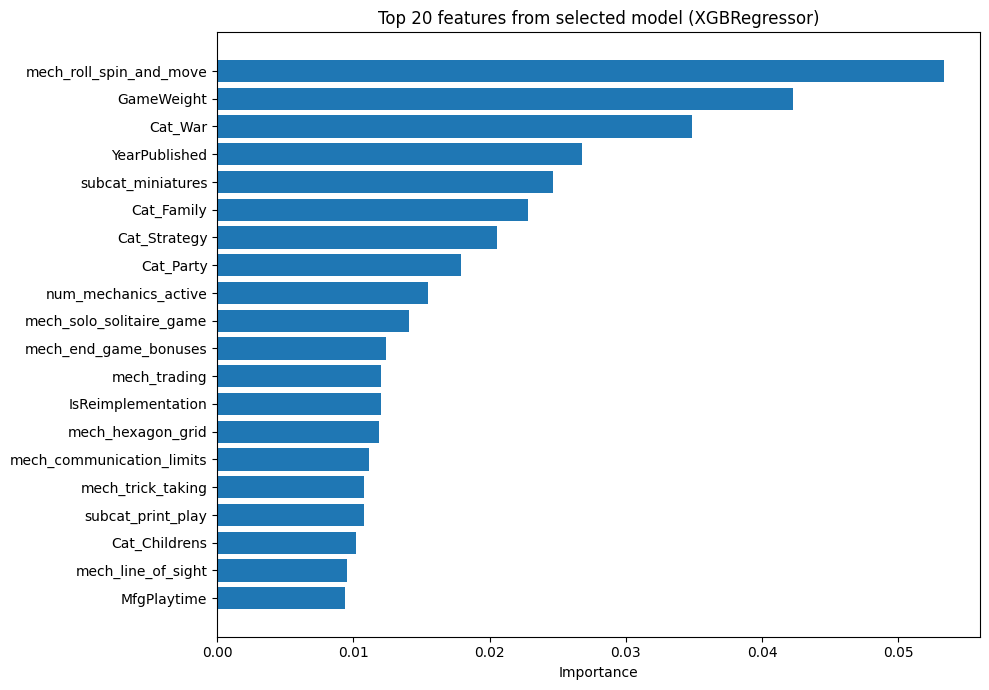

In [46]:
# Top feature importance from the current best model
fitted_model = selected_pipeline.named_steps['model']

if hasattr(fitted_model, 'feature_importances_'):
    imp_values = np.ravel(fitted_model.feature_importances_)
elif hasattr(fitted_model, 'coef_'):
    imp_values = np.abs(np.ravel(fitted_model.coef_))
else:
    imp_values = np.zeros(len(X.columns), dtype=float)

importance_df = (
    pd.DataFrame({'feature': list(X.columns), 'importance': imp_values})
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
)

top_n = 20
display(importance_df.head(top_n).round(6))

plot_df = importance_df.head(top_n).iloc[::-1]
plt.figure(figsize=(10, 7))
plt.barh(plot_df['feature'], plot_df['importance'])
plt.title(f'Top {top_n} features from selected model ({selected_model_name})')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()


### Quick interpretation notes
At this point in the notebook, wanted to pop some brief interpretation notes based on the EDA/modeling outputs completed thus far. The model comparison looks pretty coherent. XGBRegressor came out on top on validation RMSE and then held up pretty well on the true holdout test set, with only a modest RMSE gap. This suggests we are getting real signal and not just memorizing the training split.

The feature-importance output is interesting and honestly a little surprising in a good way. I was especially surprised to see the mechanic for roll spin and move at #1! It makes me consider if perhaps the mechanic could be moreso concentrated in a subset of games with a specific rating profile rather than meaning that such a simple mechanic is always better in a universal sense? In any case we're seeing strong signal here so it's certain interesting and could be worthy of further future study potentially in a theoretical follow-up on this project one day. But for now this is outside the scope of the current analytical work given the timeframe available and the focus of this project being moreso on the deployment side of things.

On the other hand, to note another observation moreso aligned to my own hypotheses about what sort of features might float to the top in importance: We do also see "GameWeight" showing up in the 2nd place position. This supports the idea that complexity still matters a lot on BGG. This in my opinion fits the community profile well due to BGG users likely being stronger enthusiasts compared to the average member out in society at large. The engineered "num_mechanics_active" feature landing in the top top (just barely admitely, at rank 9) dos also support the idea that some amount of design complexity/breadth is carrying real predictive signal too. This leads to two thoughts which, again could be considered for future ideas if ever expanded upon but will not be part of the current project scope: 1. The model may not perform quite the same way with generalized audiences versus the more specialized BGG community for the reasons noted above. And 2. There does seem to be a "ramp up" followed by a "taper-off" for the AvgRating when examining the different counts of active mechanics as well as the count of subcategories active. This could suggest  that there may be some "sweet spot" where too many concepts crammed into one game may become distasteful, while too few may not be as interesting.

I also personally enjoyed seeing the hexagon grid mechanic appear in the important feature list. It is not top-10 instead sitting at rank 14, but nonetheless it is still up there in meaningful signal. I call this one out moreso as a personal anecdote as in my opinion some of the most elegant systems in board games are built around that format. To further my personal aside, I'd call out Terra Mystica which is probably my favorite board game to play (when the time allows us at least).

To loop back on track and close out these quick interpretations though, I'd say that net/net the outputs suggest the model is picking up both broad structural signals (weight, category, mechanics count) and more specific mechanic/category effects at the same time, which is exactly the kind of combined behavior we hoped to capture with this feature set. As always the analysis and model/approach could be expounded upon in various ways, some of which are listed above and others not mentoned yet, (another thought could be more detailed analysis of the different distinct combinations of mechanic and/or subcategory features) but in any case, I think we're in a good place for the current scope and project focus for now.

From here, the next step is to make a practical cutoff decision for a parsimonious model that still has realistic predictive value but is much easier to deploy and wire into a simple fillable form for our class demo stack. So next we will examine performance at different feature-count cutoffs and tree depths, visualize the diminishing returns, and make a judgment call on where extra complexity stops being worth it. This call is somewhat subjective, and in a real-world setting we would also weigh business constraints, latency/cost targets, and input UX with other stakeholders before finalizing.


Making one final update later towards the end of this EDA and modeling process. I ran some further analysis after our final model selection to take a look at the top 4 features we are using in the final model, and the reason for the mechanic for roll spin and move is so high in importance is for it's NEGATIVE relationship with the ratings, not positive. So this does then align moreso with my own expectations and hypothesis about more nuances mechanics and strategic/complciation/weight likely being more favorable. 


In [ ]:
# XGB sweep across feature count and depth to find a practical cutoff point
# A bit over 1m runtime
try:
    from xgboost import XGBRegressor
except Exception as e:
    raise RuntimeError('xgboost is required for this section.') from e

ranked_features = importance_df['feature'].tolist() if 'importance_df' in globals() else list(X.columns)
k_values = list(range(1, 31))
depth_values = [2, 3, 4, 5, 6]
rows = []

for d in depth_values:
    for k in k_values:
        feats = ranked_features[:k]

        preproc_k = ColumnTransformer(
            transformers=[('num', Pipeline(steps=[('scaler', StandardScaler(with_mean=False))]), feats)],
            remainder='drop'
        )

        model_k = XGBRegressor(
            n_estimators=500,
            learning_rate=0.05,
            max_depth=d,
            subsample=0.9,
            colsample_bytree=0.9,
            random_state=42,
            objective='reg:squarederror',
            n_jobs=-1
        )

        pipe_k = Pipeline(steps=[('preprocessor', preproc_k), ('model', model_k)])
        pipe_k.fit(X_train[feats], y_train)

        pred_train_k = pipe_k.predict(X_train[feats])
        pred_val_k = pipe_k.predict(X_val[feats])

        train_rmse_k = float(np.sqrt(mean_squared_error(y_train, pred_train_k)))
        val_rmse_k = float(np.sqrt(mean_squared_error(y_val, pred_val_k)))

        rows.append({
            'max_depth': d,
            'feature_count': k,
            'train_RMSE': train_rmse_k,
            'val_MAE': float(mean_absolute_error(y_val, pred_val_k)),
            'val_RMSE': val_rmse_k,
            'val_R2': float(r2_score(y_val, pred_val_k)),
            'val_Spearman': safe_spearman(y_val, pred_val_k),
            'rmse_gap_val_minus_train': float(val_rmse_k - train_rmse_k)
        })

xgb_depth_grid_df = pd.DataFrame(rows).sort_values(['val_RMSE', 'val_MAE']).reset_index(drop=True)

display(xgb_depth_grid_df.head(20).round(4))

best_overall = xgb_depth_grid_df.iloc[0].to_dict()
threshold = best_overall['val_RMSE'] * 1.10
within_10pct = xgb_depth_grid_df[xgb_depth_grid_df['val_RMSE'] <= threshold].sort_values(['feature_count', 'max_depth'])
parsimonious_pick = within_10pct.iloc[0].to_dict() if not within_10pct.empty else best_overall

print('Best overall (lowest val RMSE):')
print({k: round(v, 4) if isinstance(v, (int, float, np.floating)) else v for k, v in best_overall.items()})
print()
print('Smallest model within 10% RMSE of best:')
print({k: round(v, 4) if isinstance(v, (int, float, np.floating)) else v for k, v in parsimonious_pick.items()})


,max_depth,feature_count,train_RMSE,val_MAE,val_RMSE,val_R2,val_Spearman,rmse_gap_val_minus_train
0,6,29,0.5217,0.4601,0.6172,0.5475,0.7563,0.0956
1,6,30,0.5227,0.4607,0.6186,0.5455,0.7555,0.0960
2,6,25,0.5237,0.4613,0.6192,0.5446,0.7543,0.0955
3,6,27,0.5224,0.4610,0.6193,0.5444,0.7545,0.0969
4,6,28,0.5212,0.4623,0.6195,0.5442,0.7541,0.0982
5,6,26,0.5229,0.4616,0.6198,0.5438,0.7551,0.0969
6,5,26,0.5598,0.4609,0.6200,0.5434,0.7536,0.0603
7,5,28,0.5593,0.4611,0.6205,0.5427,0.7533,0.0612
8,5,29,0.5600,0.4611,0.6207,0.5424,0.7531,0.0607
9,5,30,0.5604,0.4610,0.6208,0.5422,0.7533,0.0604


Best overall (lowest val RMSE):
{'max_depth': 6.0, 'feature_count': 29.0, 'train_RMSE': 0.5217, 'val_MAE': 0.4601, 'val_RMSE': 0.6172, 'val_R2': 0.5475, 'val_Spearman': 0.7563, 'rmse_gap_val_minus_train': 0.0956}

Smallest model within 10% RMSE of best:
{'max_depth': 2.0, 'feature_count': 4.0, 'train_RMSE': 0.6639, 'val_MAE': 0.5003, 'val_RMSE': 0.6712, 'val_R2': 0.4649, 'val_Spearman': 0.6957, 'rmse_gap_val_minus_train': 0.0073}


In [48]:


pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)
display(xgb_depth_grid_df.head(200).round(4))
pd.reset_option('display.max_rows')
pd.reset_option('display.max_colwidth')



,max_depth,feature_count,train_RMSE,val_MAE,val_RMSE,val_R2,val_Spearman,rmse_gap_val_minus_train
0,6,29,0.5217,0.4601,0.6172,0.5475,0.7563,0.0956
1,6,30,0.5227,0.4607,0.6186,0.5455,0.7555,0.0960
2,6,25,0.5237,0.4613,0.6192,0.5446,0.7543,0.0955
3,6,27,0.5224,0.4610,0.6193,0.5444,0.7545,0.0969
4,6,28,0.5212,0.4623,0.6195,0.5442,0.7541,0.0982
5,6,26,0.5229,0.4616,0.6198,0.5438,0.7551,0.0969
6,5,26,0.5598,0.4609,0.6200,0.5434,0.7536,0.0603
7,5,28,0.5593,0.4611,0.6205,0.5427,0.7533,0.0612
8,5,29,0.5600,0.4611,0.6207,0.5424,0.7531,0.0607
9,5,30,0.5604,0.4610,0.6208,0.5422,0.7533,0.0604


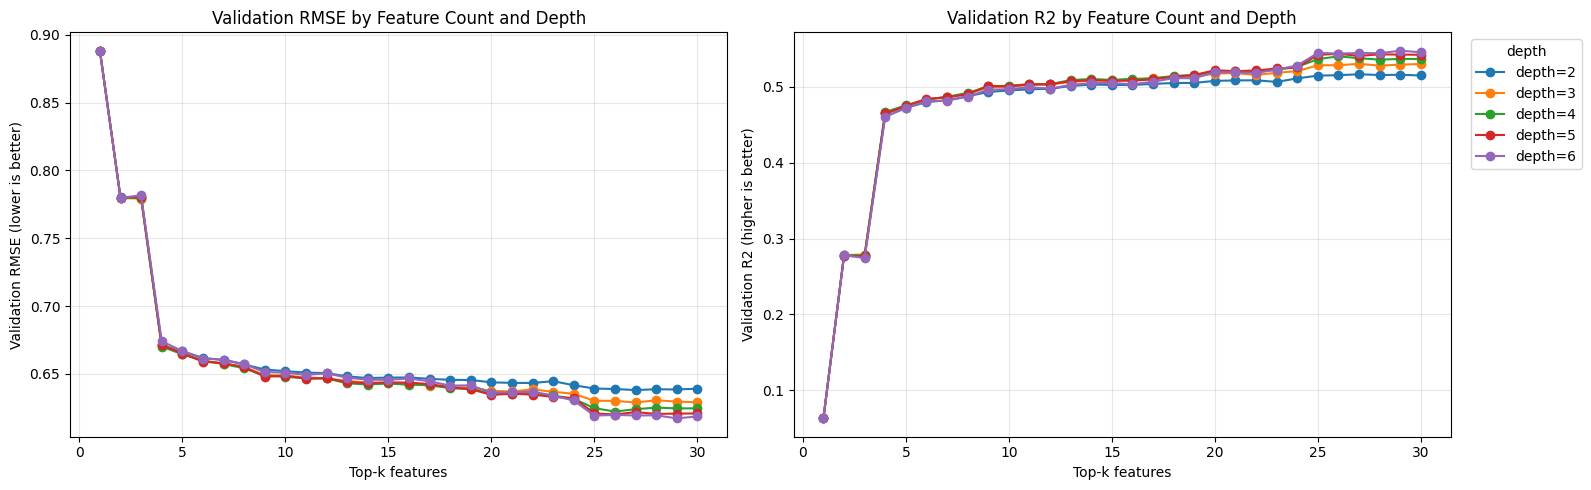

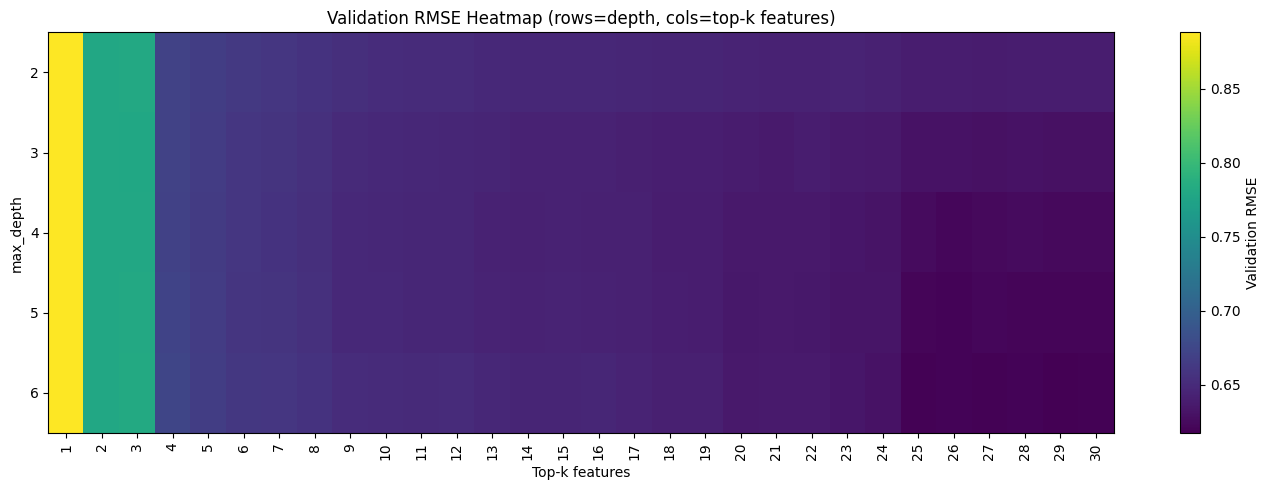

In [49]:
# Visuals for the cutoff call
plot_df = xgb_depth_grid_df.copy().sort_values(['max_depth', 'feature_count'])

fig, axes = plt.subplots(1, 2, figsize=(16, 5), sharex=True)
for d in sorted(plot_df['max_depth'].unique()):
    ddf = plot_df[plot_df['max_depth'] == d]
    axes[0].plot(ddf['feature_count'], ddf['val_RMSE'], marker='o', label=f'depth={d}')
    axes[1].plot(ddf['feature_count'], ddf['val_R2'], marker='o', label=f'depth={d}')

axes[0].set_title('Validation RMSE by Feature Count and Depth')
axes[0].set_xlabel('Top-k features')
axes[0].set_ylabel('Validation RMSE (lower is better)')
axes[0].grid(alpha=0.3)

axes[1].set_title('Validation R2 by Feature Count and Depth')
axes[1].set_xlabel('Top-k features')
axes[1].set_ylabel('Validation R2 (higher is better)')
axes[1].grid(alpha=0.3)
axes[1].legend(title='depth', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

rmse_pivot = plot_df.pivot(index='max_depth', columns='feature_count', values='val_RMSE').sort_index()
fig, ax = plt.subplots(figsize=(14, 5))
im = ax.imshow(rmse_pivot.values, aspect='auto')
ax.set_title('Validation RMSE Heatmap (rows=depth, cols=top-k features)')
ax.set_xlabel('Top-k features')
ax.set_ylabel('max_depth')
ax.set_xticks(range(len(rmse_pivot.columns)))
ax.set_xticklabels(rmse_pivot.columns, rotation=90)
ax.set_yticks(range(len(rmse_pivot.index)))
ax.set_yticklabels(rmse_pivot.index)
fig.colorbar(im, ax=ax, label='Validation RMSE')
plt.tight_layout()
plt.show()


In [50]:
pd.set_option('display.max_rows', None)
pd.set_option('display.max_colwidth', None)

xgb_k4 = xgb_depth_grid_df[xgb_depth_grid_df['feature_count'] == 4].copy()
display(xgb_k4.sort_values('max_depth').round(4))

pd.reset_option('display.max_rows')
pd.reset_option('display.max_colwidth')


,max_depth,feature_count,train_RMSE,val_MAE,val_RMSE,val_R2,val_Spearman,rmse_gap_val_minus_train
132,2,4,0.6639,0.5003,0.6712,0.4649,0.6957,0.0073
131,3,4,0.6548,0.5003,0.6712,0.4650,0.6977,0.0163
130,4,4,0.6449,0.5000,0.6701,0.4666,0.6979,0.0252
133,5,4,0.6345,0.5007,0.6713,0.4648,0.6976,0.0367
134,6,4,0.6226,0.5040,0.6741,0.4603,0.6942,0.0515


Based on the preceeding analysis and comparisons of our different potential models and configurations etc, I am choosing to proceed with the 4 feature/4 depth XGB model for this project.

This is definitely a subjective call, but I think it is a good one for the current scope. The graphs make the diminishing returns very clear: we can still capture just shy of ~50% explained variance with this very small feature set, while the higher-complexity options only add incremental lift but require many more features.

In a real-world production context, we might still decide the extra predictive power is worth the added complexity depending on business requirements. But for this project, where deployment demonstration and practical operability are our primary goals, this parsimonious configuration is much more practical: simpler input form, cleaner UX, lower runtime overhead, cheaper hosting/maintenance footprint, easier debugging, etc...

It is a little unfortunate that we lose some of the other interesting mechanics/subcategory signals in the final reduced model. That said, the analysis journey to get here was still worthwhile and gave useful insight into those effects. For the current assignment scope, this feels like a strong and defensible compromise between accuracy and simplicity, so we will now lock this configuration and move on to deployment.


In [52]:
# Fit the selected final parsimonious model: XGB depth=4 with top 4 features
from xgboost import XGBRegressor

final_k = 4
final_depth = 4
final_features = ranked_features[:final_k]

final_preprocessor = ColumnTransformer(
    transformers=[('num', Pipeline(steps=[('scaler', StandardScaler(with_mean=False))]), final_features)],
    remainder='drop'
)

final_model = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=final_depth,
    subsample=0.9,
    colsample_bytree=0.9,
    random_state=42,
    objective='reg:squarederror',
    n_jobs=-1
)

final_pipeline = Pipeline(steps=[('preprocessor', final_preprocessor), ('model', final_model)])
final_pipeline.fit(X_train, y_train)

pred_train_final = final_pipeline.predict(X_train[final_features])
pred_val_final = final_pipeline.predict(X_val[final_features])
pred_test_final = final_pipeline.predict(X_test[final_features])

final_metrics_df = pd.DataFrame([
    {
        'split': 'train',
        'MAE': mean_absolute_error(y_train, pred_train_final),
        'RMSE': np.sqrt(mean_squared_error(y_train, pred_train_final)),
        'R2': r2_score(y_train, pred_train_final),
        'Spearman': safe_spearman(y_train, pred_train_final)
    },
    {
        'split': 'validation',
        'MAE': mean_absolute_error(y_val, pred_val_final),
        'RMSE': np.sqrt(mean_squared_error(y_val, pred_val_final)),
        'R2': r2_score(y_val, pred_val_final),
        'Spearman': safe_spearman(y_val, pred_val_final)
    },
    {
        'split': 'test',
        'MAE': mean_absolute_error(y_test, pred_test_final),
        'RMSE': np.sqrt(mean_squared_error(y_test, pred_test_final)),
        'R2': r2_score(y_test, pred_test_final),
        'Spearman': safe_spearman(y_test, pred_test_final)
    }
])

print('Final selected features:')
for f in final_features:
    print('-', f)

display(final_metrics_df.round(4))
# Woot! For our holout testset it actually performs slightly better as well
# This is a nice gut-check that we likely aren't overfitting and memorizing the train and/or val sets


Final selected features:
- mech_roll_spin_and_move
- GameWeight
- Cat_War
- YearPublished


,split,MAE,RMSE,R2,Spearman
0,train,0.4866,0.6449,0.5198,0.7274
1,validation,0.5000,0.6701,0.4666,0.6979
2,test,0.5136,0.6866,0.4893,0.7135


,feature,importance
0,GameWeight,0.3303
1,YearPublished,0.2660
2,Cat_War,0.2527
3,mech_roll_spin_and_move,0.1510


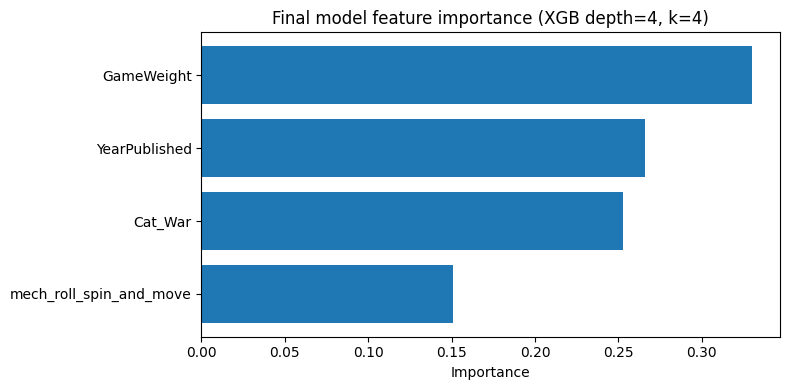

In [54]:
# Relative feature importance for the final selected model
final_fitted_model = final_pipeline.named_steps['model']
final_importance_df = (
    pd.DataFrame({
        'feature': final_features,
        'importance': np.ravel(final_fitted_model.feature_importances_)
    })
    .sort_values('importance', ascending=False)
    .reset_index(drop=True)
)

display(final_importance_df.round(6))

plot_final = final_importance_df.iloc[::-1]
plt.figure(figsize=(8, 4))
plt.barh(plot_final['feature'], plot_final['importance'])
plt.title('Final model feature importance (XGB depth=4, k=4)')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

# With the final model, the top 4 relative feature importance has shifted a bit 
# Still similar but the top 4 placement has shifted a bit from the wider full model context


<Figure size 2000x700 with 0 Axes>

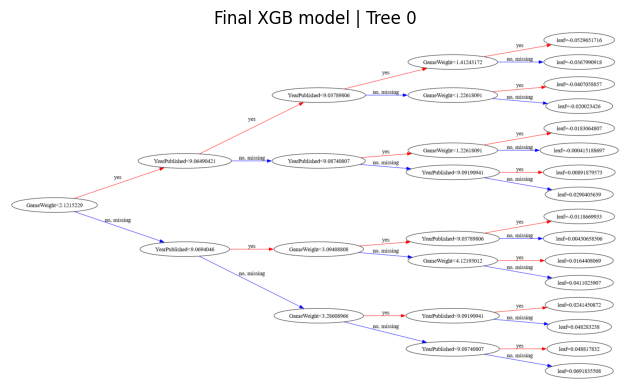

In [56]:
# Plot a readable tree for the final model
from xgboost import plot_tree

booster = final_pipeline.named_steps['model'].get_booster()
booster.feature_names = final_features

plt.figure(figsize=(20, 7))
plot_tree(final_pipeline.named_steps['model'], tree_idx=0, rankdir='LR')
plt.title('Final XGB model | Tree 0')
plt.tight_layout()
plt.show()


In [57]:
# Save final deployment artifacts
if Path('artifacts').exists():
    artifacts_dir = Path('artifacts')
elif Path('../artifacts').exists():
    artifacts_dir = Path('../artifacts')
else:
    artifacts_dir = Path('artifacts')

artifacts_dir.mkdir(parents=True, exist_ok=True)

model_path = artifacts_dir / 'model.pkl'
features_path = artifacts_dir / 'feature_columns.json'

# Refit final model on train+val before saving
final_pipeline.fit(X_train_val[final_features], y_train_val)
joblib.dump(final_pipeline, model_path)

with open(features_path, 'w', encoding='utf-8') as f:
    json.dump({'feature_columns': final_features}, f, indent=2)

print('Saved model:', model_path.resolve())
print('Saved feature list:', features_path.resolve())


Saved model: C:\Users\guy74\Documents\NU Stuff\ANA680\Week 4\Final Project Board Game Ratings Predictions\Board Game Ratings Predictions\artifacts\model.pkl
Saved feature list: C:\Users\guy74\Documents\NU Stuff\ANA680\Week 4\Final Project Board Game Ratings Predictions\Board Game Ratings Predictions\artifacts\feature_columns.json


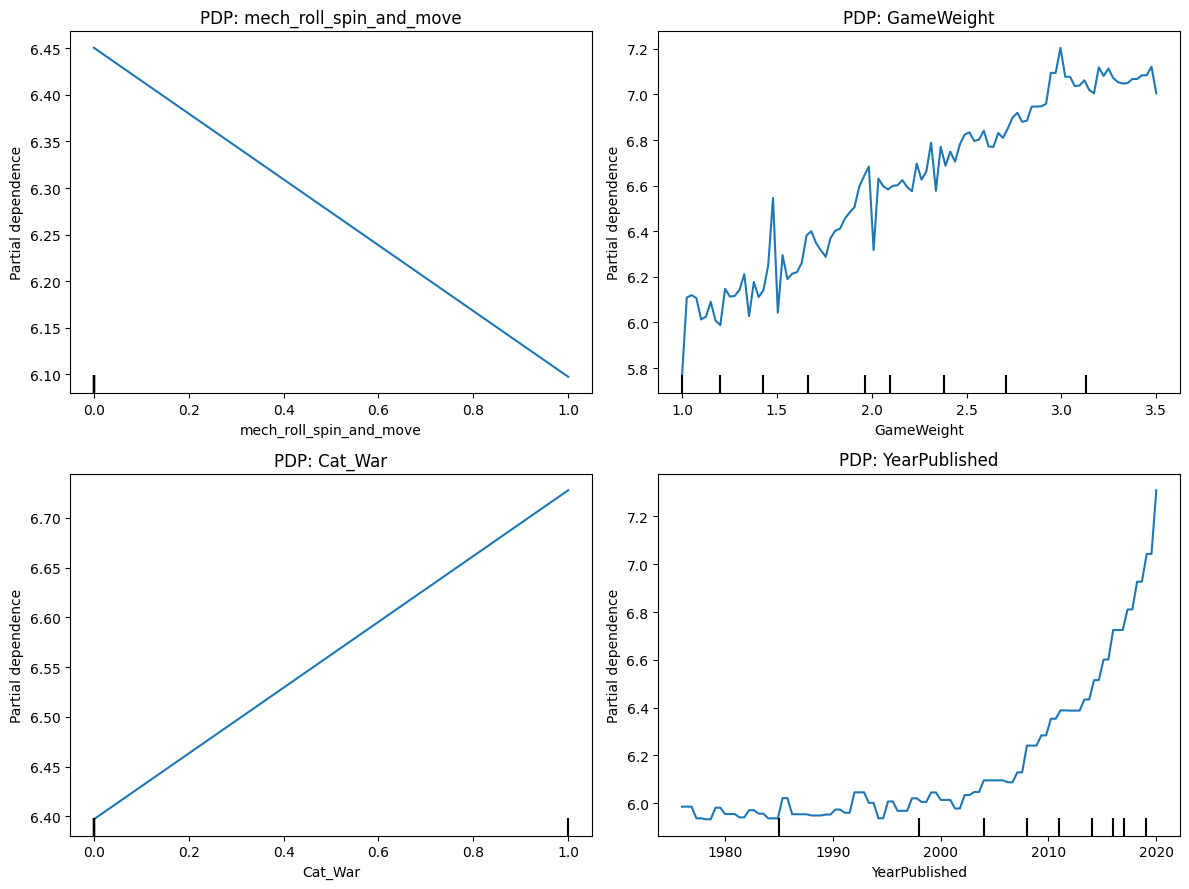

In [ ]:
# Final quick cell to give an idea on the directional read on the final 4 features (Partial Dependence Display)
# Oh! Interestingly the mechanic for roll spin and move is decidedly negative!
# So this does actually align with my original hypothesis that complexity would be a positive
# The reason this flags so high in importance is actually because it has a strong NEGATIVE relationship 

from sklearn.inspection import PartialDependenceDisplay

# Cast to float to avoid pandas dtype assignment issues inside partial dependence
X_pdp = X_train_val[final_features].astype(float).copy()

# 1) Partial dependence: general direction as each feature increases
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.ravel()

for i, feat in enumerate(final_features):
    PartialDependenceDisplay.from_estimator(
        final_pipeline,
        X_pdp,
        features=[feat],
        ax=axes[i],
        kind='average'
    )
    axes[i].set_title(f'PDP: {feat}')

plt.tight_layout()
plt.show()


GameWeight full observed range used: 0.0000 to 5.0000


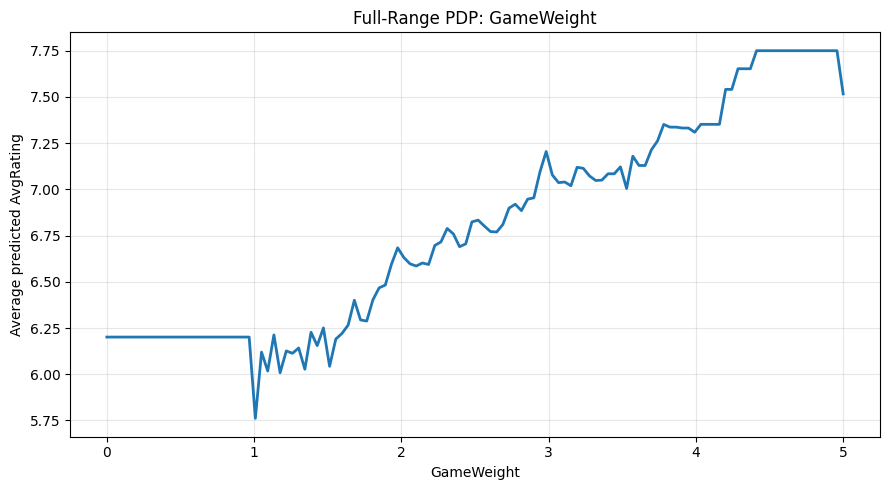

,GameWeight,avg_prediction
0,0.0000,6.2012
1,0.0420,6.2012
2,0.0840,6.2012
3,0.1261,6.2012
4,0.1681,6.2012
5,0.2101,6.2012
6,0.2521,6.2012
7,0.2941,6.2012
8,0.3361,6.2012
9,0.3782,6.2012


,GameWeight,avg_prediction
110,4.6218,7.7497
111,4.6639,7.7497
112,4.7059,7.7497
113,4.7479,7.7497
114,4.7899,7.7497
115,4.8319,7.7497
116,4.8739,7.7497
117,4.9160,7.7497
118,4.9580,7.7497
119,5.0000,7.5162


In [ ]:
# Wanted to inspect the full-range PDP for GameWeight (manual, min->max of observed data)
# Was thinking perhaps at higher weights we'd see a taper off and/or trend back down
# We do see a light one at only the highest weights, but overall it's a pretty steady positive relationship 
feature = 'GameWeight'

if feature not in final_features:
    raise ValueError(f"{feature} is not in final_features: {final_features}")

X_base = X_train_val[final_features].astype(float).copy()

fmin = float(X_base[feature].min())
fmax = float(X_base[feature].max())

# Use a dense grid over the full observed range
grid = np.linspace(fmin, fmax, 120)

avg_preds = []
for val in grid:
    X_tmp = X_base.copy()
    X_tmp.loc[:, feature] = val
    avg_preds.append(float(np.mean(final_pipeline.predict(X_tmp))))

full_range_pdp_df = pd.DataFrame({
    'GameWeight': grid,
    'avg_prediction': avg_preds
})

print(f'GameWeight full observed range used: {fmin:.4f} to {fmax:.4f}')

plt.figure(figsize=(9, 5))
plt.plot(full_range_pdp_df['GameWeight'], full_range_pdp_df['avg_prediction'], linewidth=2)
plt.title('Full-Range PDP: GameWeight')
plt.xlabel('GameWeight')
plt.ylabel('Average predicted AvgRating')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Optional quick table preview
display(full_range_pdp_df.head(10).round(4))
display(full_range_pdp_df.tail(10).round(4))
